In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [7]:
import os
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors

### Tensor Question 1

In [4]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

for name, t in [("a", a), ("b", b), ("c",c)]:
    print(f"--Tensor {name}--")
    print(f"Value: {t}")
    print(f"Shape: {t.shape}")
    print(f"Dtype: {t.dtype}")
    print(f"Device:{t.device}")

--Tensor a--
Value: tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])
Dtype: torch.float32
Device:cpu
--Tensor b--
Value: tensor([[0., 0., 0.],
        [0., 0., 0.]])
Shape: torch.Size([2, 3])
Dtype: torch.float32
Device:cpu
--Tensor c--
Value: tensor([1., 1., 1., 1.])
Shape: torch.Size([4])
Dtype: torch.float32
Device:cpu


### Tensor Question 2

In [9]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

roots = torch.sqrt(x)
print("sqrt:", roots)

total = torch.sum(x)
print("sum:", total)

aver = torch.mean(x)
print("mean:", aver)

idx= torch.argmax(x)
print("argmax:",idx )

# argmax() returns the index of the class with the highest score —
# i.e. the class the model is most confident about

sqrt: tensor([1., 2., 3., 4., 5.])
sum: tensor(55.)
mean: tensor(11.)
argmax: tensor(4)


### Tensor Question 3

In [10]:
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# .numpy() only works with CPU tensors —
# NumPy arrays live in CPU RAM, not GPU VRAM,
# that's why the tensor must be moved to CPU first

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


### Tensor Question 4

In [18]:
t = torch.arange(24).float()
t1 = t.reshape(4, 6)
print(t1.shape)

t2 = t.reshape(2,3,4)
print(t2.shape)

t3 = t1.unsqueeze(0)
print(t3.shape)

# unsqueeze(0) adds a batch dimension at position 0 —
# neural networks expect (batch_size, channels, height, width),
# even for a single image you must wrap it in a batch of 1

torch.Size([4, 6])
torch.Size([2, 3, 4])
torch.Size([1, 4, 6])


### Tensor Question 5


In [20]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

np_result = np_a @ np_b
print("NumPy:\n", np_result)

t_result = t_a @ t_b
print("PyTorch:\n", t_result)

print("Match:", np.allclose(np_result, t_result.numpy()))

# matrix multiplication is the core operation in a neural network layer —
# input data (batch) is multiplied by the layer's weights,
# transforming inputs into outputs for each neuron

NumPy:
 [[19. 22.]
 [43. 50.]]
PyTorch:
 tensor([[19., 22.],
        [43., 50.]])
Match: True


## Pretrained Models

### Model Question 1

In [8]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ResNet18 was trained on 1.2M ImageNet images for days on multiple GPUs —
# using pretrained weights means we skip that cost entirely
# and reuse what the model already learned,
# saving time and money when on a deadline or budget

Total parameters:     11,689,512
Trainable parameters: 11,689,512


### Model Question 2

In [9]:
print(model)

# 1. Final layer
# (fc): Linear(in_features=512, out_features=1000)
# 'fc' (fully connected) is the final layer —
# out_features=1000 means 1000 output scores,
# one for each ImageNet category

# 2. Deep network
# layer1 through layer4 are the feature extractor —
# each layer builds on the previous one,
# from simple edges → shapes → parts → full objects.
# "deep" means many stacked layers, each learning
# more complex features than the last

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Question 3

In [10]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

#1. moves all 11M weights to the same device as input tensors —
# model and inputs must be on the same device,
# otherwise PyTorch throws a RuntimeError

#2. switches model to evaluation mode —
# layers like Dropout behave differently:
# in training they randomly disable neurons,
# in eval all neurons are active for stable predictions

Model ready for inference.


### Model Question 4

In [11]:
preprocess = weights.transforms()
print(preprocess)

# 1. Resize + CenterCrop → 224x224
#    ResNet18 was trained on 224x224 images —
#    resize to 256 first, then crop center
#    to remove uninformative edges
#
# 2. ToTensor()
#    divides each pixel value by 255,
#    converting range 0-255 to 0.0-1.0 —
#    smaller numbers are easier for the network
#
# 3. Normalize
#    applies (pixel - mean) / std per channel
#    using ImageNet mean=[0.485, 0.456, 0.406]
#    and std=[0.229, 0.224, 0.225] —
#    real values computed from 1.2M images,
#    not guesses like 0.5

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference

In [14]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


In [ ]:
### Inference Question 1

In [17]:
def get_top5_predictions(model, preprocess, image, device, class_labels):

    tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)

    probs = torch.nn.functional.softmax(output[0], dim = 0)

    top_probs, top_indices = torch.topk(probs, 5)

    results = []
    for i in range(5):
        class_name = class_labels[top_indices[i]]
        probability = top_probs[i].item()
        results.append((class_name, probability))
    return results
    

In [43]:
img, img_name = load_sample_image("mountain")
preds         = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# Top prediction 'alp' makes sense — it's ImageNet's label for alpine mountains.
# All top-5 labels (alp, valley, ski, volcano) map onto a mountain scene,
# showing that even without an exact 'mountain' class,
# the model correctly identifies the scene type


Top-5 predictions for '19756.jpg':
  alp                             0.3068
  valley                          0.1986
  promontory                      0.0755
  seashore                        0.0505
  volcano                         0.0479


### Inference Question 2

In [44]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# Most confident: glacier (74%) and sea (44%) —
# ImageNet has similar classes like 'alp' and 'seashore'

# Least confident: forest (8%) and mountain (15%) —
# ImageNet was built for object recognition, not scene classification.
# Classes like 'forest' and 'street' don't exist in ImageNet,
# so the model struggles when no close match is available


[buildings]  17718.jpg
  turnstile                       0.5445
  nail                            0.3589
  microphone                      0.0285

[forest]  269.jpg
  mountain bike                   0.0800
  mountain tent                   0.0790
  suspension bridge               0.0739

[glacier]  15103.jpg
  alp                             0.7389
  volcano                         0.1049
  valley                          0.0529

[mountain]  5885.jpg
  alp                             0.1543
  volcano                         0.1400
  geyser                          0.1202

[sea]  15025.jpg
  seashore                        0.4427
  sandbar                         0.1376
  promontory                      0.0532

[street]  6011.jpg
  dock                            0.2097
  drilling platform               0.1012
  seashore                        0.0675


### Inference Question 3

In [48]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

# Neural networks output logits internally because:
# - logits are faster to compute during training
# - softmax is only needed at the very end

# For filtering low-confidence predictions in production,
# use probabilities — they are scaled 0.0 to 1.0,
# so a threshold like "if prob > 0.8" is intuitive.
# Logits have no fixed range, making thresholds meaningless.

Logit  range: min=-4.44, max=6.09
Prob   range: min=0.000002, max=0.0773
Probs sum to: 1.000000
Top prediction: worm fence  (0.0773)


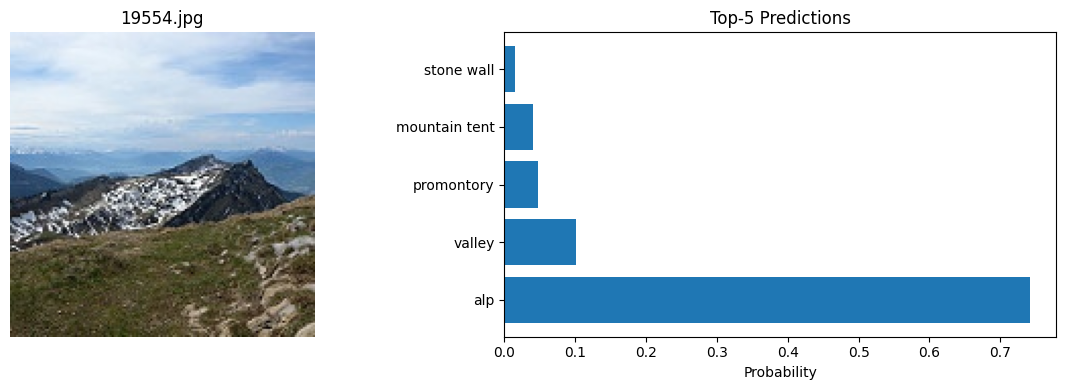

In [53]:
import matplotlib.pyplot as plt
import os

os.makedirs("outputs", exist_ok=True)
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(img)
ax1.axis("off")
ax1.set_title(img_name)

names  = [name for name, prob in preds]
values = [prob for name, prob in preds]

ax2.barh(names, values)
ax2.set_xlabel("Probability")
ax2.set_title("Top-5 Predictions")

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()